# DMALA alpha scan at several training checkpoints

This notebook loads a trained one-layer MLP BEBM, selects 5 checkpoints approximately linearly spaced between the beginning and the end of training, and for each checkpoint measures:

- the exponential decorrelation time $\tau_{\mathrm{exp}}(\alpha)$,
- the mean DMALA acceptance rate as a function of $\alpha$.


In [41]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from rbms.io import load_params
from rbms.utils import get_saved_updates

device = "cuda:0" if torch.cuda.is_available() else "cpu"
dtype = torch.float32

MODEL_FILE = "pcd_trains/BEBM_MLP_MNIST_h500_DMALA100_lr1e-2_100k.h5"
NUM_CHECKPOINTS = 5
ALPHAS = np.array([
    0.01, 0.02, 0.03, 0.05, 0.07, 0.09,
    0.10, 0.11, 0.12, 0.13, 0.14,
    0.15, 0.16, 0.17, 0.18, 0.19,
    0.20, 0.21, 0.22, 0.23, 0.24,
    0.25, 0.26, 0.27, 0.28, 0.29,
    0.30, 0.31, 0.32, 0.34, 0.36,
    0.38, 0.40,
    0.45, 0.50, 0.60, 0.75, 0.90, 1.00,
], dtype=float)
NUM_CHAINS = 512
NUM_STEPS = 15000
MAX_LAG = 10000
FFT_COMPONENT_BATCH = 512
BETA = 1.0
FIT_MIN_RHO = 0.05
FIT_MAX_RHO = 0.6
SEED = 0

saved_updates = get_saved_updates(MODEL_FILE)
target_updates = np.linspace(int(saved_updates[0]), int(saved_updates[-1]), NUM_CHECKPOINTS)
scan_updates = []
for target in target_updates:
    index = np.argmin(np.abs(saved_updates - target))
    scan_updates.append(int(saved_updates[index]))
scan_updates = sorted(set(scan_updates))

print("device:", device)
print("model file:", MODEL_FILE)
print("selected checkpoints:", scan_updates)
print("alphas:", ALPHAS)


device: cuda:0
model file: pcd_trains/BEBM_MLP_MNIST_h500_DMALA100_lr1e-2_100k.h5
selected checkpoints: [1, 25025, 50050, 74975, 100000]
alphas: [0.01 0.02 0.03 0.05 0.07 0.09 0.1  0.11 0.12 0.13 0.14 0.15 0.16 0.17
 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28 0.29 0.3  0.31
 0.32 0.34 0.36 0.38 0.4  0.45 0.5  0.6  0.75 0.9  1.  ]


In [42]:
def dmala_step_energy(energy, visible, alpha, beta=1.0):
    visible_in = visible.detach().requires_grad_(True)
    current_energy = energy(visible_in).view(-1)
    grad = torch.autograd.grad(current_energy.sum(), visible_in)[0]

    forward_logits = -0.5 * beta * grad + (2.0 * visible_in - 1.0) / (2.0 * alpha)
    forward_prob = torch.sigmoid(forward_logits)
    proposal = torch.bernoulli(forward_prob).detach()

    proposal_in = proposal.requires_grad_(True)
    proposal_energy = energy(proposal_in).view(-1)
    proposal_grad = torch.autograd.grad(proposal_energy.sum(), proposal_in)[0]

    reverse_logits = -0.5 * beta * proposal_grad + (2.0 * proposal_in - 1.0) / (2.0 * alpha)

    with torch.no_grad():
        log_q_forward = -F.binary_cross_entropy_with_logits(
            forward_logits.detach(), proposal, reduction="none"
        ).sum(dim=1)
        log_q_reverse = -F.binary_cross_entropy_with_logits(
            reverse_logits.detach(), visible, reduction="none"
        ).sum(dim=1)

        log_acceptance = (
            -beta * proposal_energy.detach()
            + beta * current_energy.detach()
            + log_q_reverse
            - log_q_forward
        )

        accept = torch.log(torch.rand_like(log_acceptance)) < log_acceptance
        new_visible = torch.where(accept[:, None], proposal, visible)

    return new_visible, accept.float().mean().item()


def spin_autocorr_fft(spins, max_lag, component_batch=2048, fft_device=None):
    if fft_device is None:
        fft_device = device

    num_times, num_chains, num_visibles = spins.shape
    max_lag = min(int(max_lag), num_times - 1)

    mean_spin = spins.to(torch.float32).mean(dim=(0, 1)).cpu()
    flat = spins.reshape(num_times, num_chains * num_visibles)
    n_fft = 1 << (2 * num_times - 1).bit_length()

    counts = torch.arange(
        num_times,
        num_times - max_lag - 1,
        -1,
        device=fft_device,
        dtype=torch.float32,
    )

    numerator = torch.zeros(max_lag + 1, dtype=torch.float64)
    denominator = torch.tensor(0.0, dtype=torch.float64)

    for col_start in tqdm(range(0, flat.shape[1], component_batch), leave=False):
        col_stop = min(col_start + component_batch, flat.shape[1])
        block = flat[:, col_start:col_stop].to(device=fft_device, dtype=torch.float32)

        pixel_indices = torch.arange(col_start, col_stop, device="cpu") % num_visibles
        block = block - mean_spin[pixel_indices].to(fft_device).view(1, -1)

        block_fft = torch.fft.rfft(block, n=n_fft, dim=0)
        autocov = torch.fft.irfft(block_fft.abs().square(), n=n_fft, dim=0)[: max_lag + 1]
        autocov = autocov / counts[:, None]

        numerator += autocov.sum(dim=1).detach().cpu().double()
        denominator += autocov[0].sum().detach().cpu().double()

    return (numerator / denominator.clamp_min(1e-12)).numpy()


def collect_spin_trajectory_dmala(energy, num_visibles, num_chains, num_steps, alpha, beta=1.0, seed=0):
    torch.manual_seed(seed)
    visible = torch.bernoulli(
        torch.full((num_chains, num_visibles), 0.5, device=device, dtype=dtype)
    )

    spin_trajectory = torch.empty(
        (num_steps + 1, num_chains, num_visibles), device="cpu", dtype=torch.int8
    )
    acceptances = []

    for step in range(num_steps + 1):
        spin_trajectory[step].copy_((2.0 * visible.detach().cpu() - 1.0).to(torch.int8))

        if step < num_steps:
            visible, acceptance = dmala_step_energy(energy, visible, alpha=alpha, beta=beta)
            acceptances.append(acceptance)

    mean_acceptance = float(np.mean(acceptances)) if acceptances else np.nan
    return spin_trajectory, mean_acceptance


def fit_tau_exp(rho, fit_min_rho=0.05, fit_max_rho=0.6):
    lags = np.arange(len(rho))
    fit_mask = (lags > 0) & np.isfinite(rho) & (rho > fit_min_rho) & (rho < fit_max_rho)

    if fit_mask.sum() < 2:
        return np.nan

    slope, intercept = np.polyfit(lags[fit_mask], np.log(rho[fit_mask]), deg=1)
    return -1.0 / slope if slope < 0 else np.inf


In [43]:
results = {}

for update in scan_updates:
    params = load_params(MODEL_FILE, update, device=device, dtype=dtype)
    energy = params.energy
    num_visibles = params.num_visibles

    results[update] = {}
    for alpha in tqdm(ALPHAS, desc=f"alpha scan update {update}"):
        spins, acceptance = collect_spin_trajectory_dmala(
            energy=energy,
            num_visibles=num_visibles,
            num_chains=NUM_CHAINS,
            num_steps=NUM_STEPS,
            alpha=float(alpha),
            beta=BETA,
            seed=SEED,
        )

        rho = spin_autocorr_fft(
            spins=spins,
            max_lag=MAX_LAG,
            component_batch=FFT_COMPONENT_BATCH,
            fft_device=device,
        )

        tau_exp = fit_tau_exp(
            rho=rho,
            fit_min_rho=FIT_MIN_RHO,
            fit_max_rho=FIT_MAX_RHO,
        )

        results[update][float(alpha)] = {
            "tau_exp": tau_exp,
            "acceptance": acceptance,
        }
        del spins
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print(f"update={update}, alpha={alpha:.3f}: acceptance={acceptance:.4f}, tau_exp={tau_exp:.2f}")


alpha scan update 1:   0%|          | 0/39 [00:00<?, ?it/s]

alpha scan update 1:   3%|▎         | 1/39 [00:27<17:13, 27.20s/it]

update=1, alpha=0.010: acceptance=1.0000, tau_exp=nan


alpha scan update 1:   5%|▌         | 2/39 [00:54<16:50, 27.31s/it]

update=1, alpha=0.020: acceptance=1.0000, tau_exp=nan


...

update=100000, alpha=0.750: acceptance=0.0026, tau_exp=23868.73


alpha scan update 100000:  97%|█████████▋| 38/39 [33:18<00:54, 54.86s/it]

update=100000, alpha=0.900: acceptance=0.0022, tau_exp=24381.57


alpha scan update 100000: 100%|██████████| 39/39 [34:13<00:00, 52.65s/it]

update=100000, alpha=1.000: acceptance=0.0021, tau_exp=23043.47


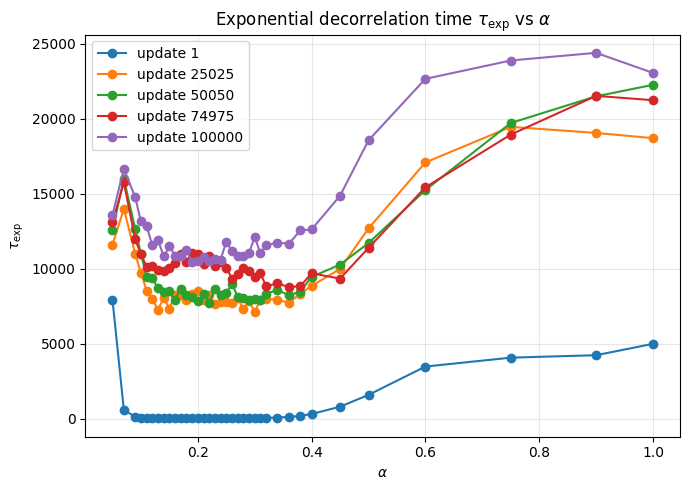

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

for update in scan_updates:
    alphas = np.array(sorted(results[update].keys()))
    tau_values = np.array([results[update][alpha]["tau_exp"] for alpha in alphas])
    ax.plot(alphas, tau_values, marker="o", label=f"update {update}")

ax.set_title(r"Exponential decorrelation time $\tau_{\mathrm{exp}}$ vs $\alpha$")
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\tau_{\mathrm{exp}}$")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


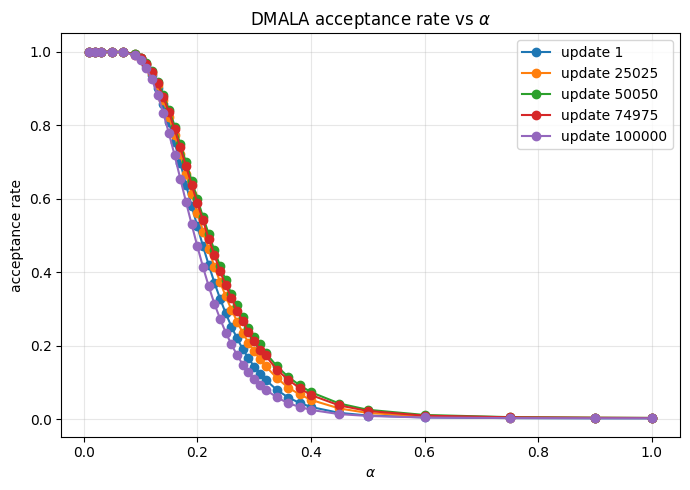

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

for update in scan_updates:
    alphas = np.array(sorted(results[update].keys()))
    acceptance_values = np.array([results[update][alpha]["acceptance"] for alpha in alphas])
    ax.plot(alphas, acceptance_values, marker="o", label=f"update {update}")

ax.set_title(r"DMALA acceptance rate vs $\alpha$")
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("acceptance rate")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [46]:
{k: sorted(v.keys()) for k, v in results.items()}
for update in scan_updates:
    alphas = np.array(sorted(results[update].keys()))
    tau_values = np.array([results[update][alpha]["tau_exp"] for alpha in alphas])
    print(update, tau_values)


1 [          nan           nan           nan 7924.46384142  576.68670148
  118.78094417   68.71057639   44.51189098   31.39960078   23.77504941
   19.00568347   15.9690741    13.98839908   12.66648237   11.85648662
   11.43126817   11.30964921   11.44144606   11.87074989   12.58161257
   13.62056666   15.07535226   16.91637392   19.36878848   22.53133914
   26.56259152   31.60418165   37.9597458    47.05359079   71.80983673
  115.15094533  179.28519821  307.17368753  792.28988788 1581.63342203
 3469.22162391 4063.39837718 4225.26939558 4985.01594522]
25025 [           nan            nan            nan 11583.47230375
 13974.55367414 10979.14254004  9706.77188509  8534.4423864
  7949.28209136  7267.32895718  8035.7117154   7337.22299625
  8232.26885701  8247.96692372  7886.48382679  8282.39414613
  8518.28844469  7911.31111479  8252.78526717  7641.42465526
  7744.51540326  7797.54248618  7700.30496201  8037.04655296
  7295.13661642  7820.83696896  7117.73125324  7923.40178656
  7988.7564